# End-to-End LLM Project with RAG, Tavily, and CrewAI

This notebook builds a complete question-answering workflow with:
- a local knowledge base from the `crew_data/` folder
- FAISS-based retrieval for RAG
- live web search through Tavily
- a CrewAI pipeline with Researcher, Writer, and Critic agents

The design follows the project brief closely, but it also adds a few quality-of-life improvements:
- `.env` loading instead of hardcoding secrets
- support for multiple source documents instead of one fixed PDF
- a cleaner CrewAI workflow that keeps the grounded evidence visible to the final reviewer
- comments written in a natural, human style


## What This Notebook Covers

Requirement check:
- `langchain`, `tavily-python`, and `groq`-compatible LangChain integration
- document loading from `crew_data/`
- chunking with `RecursiveCharacterTextSplitter`
- embeddings plus FAISS indexing
- retrieval-based QA
- Tavily web search for fresh information
- CrewAI agents for research, writing, and review
- an extra trend analyst agent
- a markdown report generator

Note on embeddings: the brief mentions OpenAI embeddings. This notebook uses `OpenAIEmbeddings` when `OPENAI_API_KEY` is present, and falls back to a local Hugging Face embedding model otherwise so the project still runs with only Groq and Tavily keys.


In [1]:
%pip install -q crewai crewai-tools langchain langchain-classic langchain-community langchain-groq langchain-openai langchain-text-splitters tavily-python faiss-cpu pypdf sentence-transformers matplotlib scikit-learn
%pip install langchain-google-genai
%pip install litellm

In [2]:
# If you just installed packages above in a fresh environment, restart the kernel once before running the imports below.

In [3]:
import os
from datetime import datetime
from pathlib import Path

from tavily import TavilyClient

from crewai import Agent, Crew, LLM, Process, Task
from crewai.tools import tool

from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_groq import ChatGroq

# from langchain_openai import OpenAIEmbeddings
from langchain_google_genai import GoogleGenerativeAIEmbeddings

from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter


def load_env_file(env_path: Path, override: bool = True):
    if not env_path.exists():
        return

    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue

        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")

        if override or key not in os.environ:
            os.environ[key] = value


In [ ]:
load_env_file(Path.cwd() / ".env", override=True)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "crew_data"
REPORTS_DIR = PROJECT_DIR / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
# OPENAI_API_KEY = os.getenv("OPE NAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

os.environ["GROQ_API_KEY"] = GROQ_API_KEY
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

if not GROQ_API_KEY:
    raise ValueError("Missing GROQ_API_KEY. Add it to .env before running the notebook.")

if not TAVILY_API_KEY:
    raise ValueError("Missing TAVILY_API_KEY. Add it to .env before running the notebook.")

if not DATA_DIR.exists():
    raise FileNotFoundError("The crew_data folder is missing. Create it and add your documents first.")

print(f"Project directory: {PROJECT_DIR}")
print(f"Knowledge base folder: {DATA_DIR}")
print(f"Reports folder: {REPORTS_DIR}")
# print("Embeddings provider:", "OpenAI" if OPENAI_API_KEY else "HuggingFace fallback")
print("Embeddings provider:", "Gemeni" if GOOGLE_API_KEY else "HuggingFace fallback")


Project directory: /content
Knowledge base folder: /content/crew_data
Reports folder: /content/reports
Embeddings provider: Gemeni


## Step 1: Load and Chunk the Documents

The project brief says the notebook should read from a `crew_data/` folder, so this version loads every supported file in that folder instead of relying on a single hardcoded PDF.


In [5]:
def load_documents(data_dir: Path):
    documents = []
    supported_patterns = ["*.pdf", "*.txt", "*.md"]
    ignored_names = {"readme.md"}

    for pattern in supported_patterns:
        for file_path in sorted(data_dir.rglob(pattern)):
            if file_path.name.lower() in ignored_names:
                continue

            if file_path.suffix.lower() == ".pdf":
                loader = PyPDFLoader(str(file_path))
            else:
                loader = TextLoader(str(file_path), encoding="utf-8")

            loaded_docs = loader.load()
            for doc in loaded_docs:
                doc.metadata["source"] = str(file_path.name)
            documents.extend(loaded_docs)

    if not documents:
        raise ValueError("No supported files were found in crew_data. Add a PDF, TXT, or MD file and rerun.")

    return documents


raw_documents = load_documents(DATA_DIR)

# These chunk settings are a good starting point for class-sized documents.
# They keep enough context to answer questions, while still staying retriever-friendly.
splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=150)
chunks = splitter.split_documents(raw_documents)

print(f"Loaded {len(raw_documents)} document units")
print(f"Created {len(chunks)} chunks for retrieval")


Loaded 6 document units
Created 39 chunks for retrieval


In [6]:
# import google.generativeai as genai
# genai.configure(api_key=GOOGLE_API_KEY)

# for m in genai.list_models():
#     if "embedContent" in m.supported_generation_methods:
#         print(m.name)

In [7]:
def build_embeddings():
    # if OPENAI_API_KEY:
    #     return OpenAIEmbeddings(model="text-embedding-3-small", api_key=OPENAI_API_KEY)

    if GOOGLE_API_KEY:
        print('GOOGLE_API_KEY is available.')
        return GoogleGenerativeAIEmbeddings(
            model="models/gemini-embedding-001",
            google_api_key=GOOGLE_API_KEY
        )

    # Fallback keeps the notebook usable even if only Groq and Tavily keys are available.
    return HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


embeddings = build_embeddings()
vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

print("FAISS index is ready")


GOOGLE_API_KEY is available.
FAISS index is ready


## Step 2: Retrieval-Augmented QA

This section creates a standard RAG pipeline on top of the FAISS index. It is useful both for testing the vectorstore and for the student task that asks you to explore retrieval directly.


In [30]:
# LangChain LLM for the retrieval QA chain
rag_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.1,
    groq_api_key=GROQ_API_KEY,
)

crew_llm = LLM(
    model="groq/meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0.1,
)

qa_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user's question using only the provided context. "
            "If the answer is not in the context, say you do not know.\n\n"
            "Context:\n{context}",
        ),
        ("human", "{input}"),
    ]
)

document_chain = create_stuff_documents_chain(rag_llm, qa_prompt)
qa_chain = create_retrieval_chain(retriever, document_chain)


def ask_local_knowledge_base(question: str):
    result = qa_chain.invoke({"input": question})
    answer = result["answer"]
    sources = []

    for doc in result["context"]:
        source_name = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page")
        if page is None:
            sources.append(source_name)
        else:
            sources.append(f"{source_name} (page {page + 1})")

    return answer, sorted(set(sources))


sample_question = "What are the main ideas discussed in the local documents?"
sample_answer, sample_sources = ask_local_knowledge_base(sample_question)
print("Question:", sample_question)
print("Answer:", sample_answer)
print("Sources:", sample_sources)

Question: What are the main ideas discussed in the local documents?
Answer: The main ideas discussed in the local documents are:

1. The importance of clinical summarization in healthcare, which involves condensing unstructured patient information into a concise, accessible format.
2. The role of clinical summarization in improving healthcare delivery, patient health outcomes, and hospital expenditures.
3. The challenges clinicians face in approaching clinical summarization, including time constraints and varying levels of effort.
4. The impact of generative AI on clinical summarization and workflows in the healthcare industry.
5. The significance of effective summarization of unstructured patient data in electronic health records (EHRs) for accurate diagnosis and efficient patient care.
6. The need for clinicians to have an effective understanding of a patient's medical history and current health status to develop accurate differentials and management plans.
Sources: ['doc.pdf (page 1

In [31]:
from langchain_groq import ChatGroq

print("Attempting to initialize ChatGroq client...")
try:
    # Using 'llama-3.1-8b-instant' as a widely available model for testing.
    test_llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.1, groq_api_key=GROQ_API_KEY)

    print("ChatGroq client initialized successfully.")

    print("Attempting a simple chat completion...")
    response = test_llm.invoke("Hello, how are you?")
    print("Simple chat completion successful!")
    print(f"Response: {response.content[:100]}...")
    print("\nYour Groq API key appears to be configured correctly and able to access the specified model.")
except Exception as e:
    print(f"An error occurred: {e}")
    if "invalid_api_key" in str(e):
        print("This suggests an issue with your GROQ_API_KEY. Please ensure it is correct and not expired.")
    elif "model_not_found" in str(e) or "does not exist or you do not have access to it" in str(e):
        print("This suggests the specified model is not available or you don't have access to it. Please check Groq's documentation for available models.")
    else:
        print("Please review the error message to diagnose the problem.")


Attempting to initialize ChatGroq client...
ChatGroq client initialized successfully.
Attempting a simple chat completion...
Simple chat completion successful!
Response: Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm funct...

Your Groq API key appears to be configured correctly and able to access the specified model.


## Step 3: Tavily Web Search

Tavily handles fresh information that may not exist in the local knowledge base. This is the part that helps the system stay useful for current topics.


In [32]:
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


def run_tavily_search(query: str, max_results: int = 5) -> str:
    results = tavily_client.search(query=query, max_results=max_results, search_depth="advanced")
    cleaned_results = []

    for idx, item in enumerate(results.get("results", []), start=1):
        cleaned_results.append(
            f"[{idx}] {item.get('title', 'Untitled')}\n"
            f"URL: {item.get('url', 'N/A')}\n"
            f"Content: {item.get('content', 'No summary returned.')}"
        )

    return "\n\n".join(cleaned_results)


print(run_tavily_search("latest advancements in LLMs")[:800])


[1] The State Of LLMs 2025: Progress, Problems, and Predictions
URL: https://magazine.sebastianraschka.com/p/state-of-llms-2025
Content: To wrap things up, I think if there is one meta-lesson from 2025, it is that progress in LLMs is less about a single breakthrough, and improvements are being made on multiple fronts via multiple independent levers. This includes architecture tweaks, data quality improvements, reasoning training, inference scaling, tool calling, and more.

At the same time, evaluation remains hard, benchmarks are imperfect, and good judgment about when and how to use these systems is still essential.

My hope for 2026 is that we continue to see interesting improvements, but also that we understand where the improvements are coming from. This requires both better and more c


## Step 4: CrewAI Tools and Core Agent Team

The original notebook tried to build a larger routing-and-grading chain, but one of its tasks accidentally asked the hallucination checker to validate the word `yes` or `no` instead of the real answer. This version keeps the workflow simpler and safer:
- the Researcher gathers grounded evidence from local documents and the web
- the Writer turns the evidence into a structured answer
- the Critic checks factual grounding, clarity, and completeness before returning the final version


In [33]:
@tool("search_knowledge_base")
def search_knowledge_base(question: str) -> str:
    """Search the local FAISS index and return the most relevant passages."""
    matches = vectorstore.similarity_search(question, k=4)
    formatted_matches = []

    for idx, doc in enumerate(matches, start=1):
        source_name = doc.metadata.get("source", "unknown")
        page = doc.metadata.get("page")
        location = source_name if page is None else f"{source_name} (page {page + 1})"
        formatted_matches.append(f"[{idx}] {location}\n{doc.page_content}")

    return "\n\n".join(formatted_matches)


@tool("search_web")
def search_web(question: str) -> str:
    """Search the web with Tavily and return concise result summaries."""
    return run_tavily_search(question, max_results=5)


researcher = Agent(
    role="Researcher",
    goal="Find the most relevant facts from the local knowledge base and the live web when needed.",
    backstory=(
        "You are a careful research assistant. You prefer grounded evidence, "
        "you separate local-document findings from web findings, and you never invent sources."
    ),
    tools=[search_knowledge_base, search_web],
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

writer = Agent(
    role="Content Writer",
    goal="Turn research notes into a clean, detailed answer that is easy to follow.",
    backstory=(
        "You are a strong technical writer. You organize information clearly, "
        "keep the answer readable, and avoid adding claims that were not researched."
    ),
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

critic = Agent(
    role="Reviewer",
    goal="Check whether the final answer is accurate, complete, and properly grounded in the research.",
    backstory=(
        "You are the final quality gate. You remove weak claims, tighten vague wording, "
        "and make sure the answer actually addresses the question."
    ),
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

In [34]:
def build_qa_crew(question: str) -> Crew:
    research_task = Task(
        description=(
            f"Research the following question: {question}\n\n"
            "Use the local knowledge base first whenever it is relevant. "
            "Use Tavily web search for recent facts, missing context, or current developments.\n"
            "Return well-organized research notes with clear source labels."
        ),
        expected_output="Structured research notes with grounded facts and source labels.",
        agent=researcher,
    )

    writing_task = Task(
        description=(
            f"Write a detailed answer for this question: {question}\n\n"
            "Use only the research notes you were given. "
            "Keep the structure clear and make sure the reasoning is easy to follow."
        ),
        expected_output="A well-structured answer based only on the research notes.",
        agent=writer,
        context=[research_task],
    )

    review_task = Task(
        description=(
            f"Review the draft answer for this question: {question}\n\n"
            "Check factual grounding, clarity, and completeness. "
            "Return the improved final answer, followed by a short 'Sources' section."
        ),
        expected_output="A polished final answer with a short Sources section.",
        agent=critic,
        context=[research_task, writing_task],
    )

    return Crew(
        agents=[researcher, writer, critic],
        tasks=[research_task, writing_task, review_task],
        process=Process.sequential,
        verbose=True,
    )


question = "How does retrieval-augmented generation help reduce hallucinations in LLM applications?"
qa_crew = build_qa_crew(question)
crew_answer = qa_crew.kickoff()
print(crew_answer)


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 67b4121f-0cd0-4068-aa8f-daebdbd73fd9                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the following question: How does retrieval-augmented generation help reduce hallucinations in   │
│  LLM applications?                                                                                              │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│  ID: 01a249c5-3cc3-4bf9-ae1c-3c6d5b837a05                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Task: Research the following question: How does retrieval-augmented generation help reduce hallucinations in   │
│  LLM applications?                                                                                              │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  I'll start by searching the local knowledge base to see if there's any relevant information on                 │
│  retrieval-augmented generation and its impact on hallucinations in LLM applications.                           │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Research the following question: How does retrieval-augmented generation help reduce hallucinations in   │
│  LLM applications?                                                                                              │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **Retrieval-Augmented Generation: A Technique to Reduce Hallucinations in LLM Applications**                   │
│                                                                                                                 │
│  Retrieval-augmented generation is a technique designed to enhance the performance of Large Language Models     │
│  (LLMs) by incorporating external information retrieval into the generation process. This approach has been     │
│  specifically noted to help mitigate a common issue with LLMs: hallucinations. Hallucinations refer to          │
│  instances where LLMs generate information that is not based on any actual input or training data, leading to   │
│  potentially inaccurate or fabricated responses.                                                                │
│                                                                                                                 │
│  The traditional generation process in LLMs relies solely on the model's internal knowledge and parameters to   │
│  produce responses. However, this reliance on internal knowledge can sometimes lead to inaccuracies,            │
│  especially when the model encounters queries that are outside its training data or require very specific,      │
│  up-to-date information.                                                                                        │
│                                                                                                                 │
│  Retrieval-augmented generation addresses this challenge by first retrieving relevant information from an       │
│  external knowledge base or database based on the input query. This retrieved information is then used to       │
│  augment the model's generation process. The integration of external information in this way helps ensure that  │
│  the model's responses are grounded in factual data, thereby reducing the likelihood of hallucinations.         │
│                                                                                                                 │
│  The process can be broken down into several key steps:                                                         │
│                                                                                                                 │
│  1. **Query Analysis**: The input query is analyzed to identify key concepts and terms that can be used for     │
│  information retrieval.                                                                                         │
│                                                                                                                 │
│  2. **Information Retrieval**: Relevant documents or data are retrieved from an external knowledge base using   │
│  the query terms. This step is crucial as it provides the model with accurate and context-specific              │
│  information.                                                                                                   │
│                                                                                                                 │
│  3. **Augmentation and Generation**: The retrieved information is then fed into the LLM along with the          │
│  original query. The model uses this augmented input to generate a response. The presence of accurate,          │
│  retrieved information helps guide the generation proce

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Review the draft answer for this question: How does retrieval-augmented generation help reduce           │
│  hallucinations in LLM applications?                                                                            │
│                                                                                                                 │
│  Check factual grounding, clarity, and completeness. Return the improved final answer, followed by a short      │
│  'Sources' section.                                                                                             │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 67b4121f-0cd0-4068-aa8f-daebdbd73fd9                                                                       │
│  Final Output: **Retrieval-Augmented Generation: A Technique to Reduce Hallucinations in LLM Applications**     │
│                                                                                                                 │
│  Retrieval-augmented generation is a technique designed to enhance the performance of Large Language Models     │
│  (LLMs) by incorporating external information retrieval into the generation process. This approach has been     │
│  specifically noted to help mitigate a common issue with LLMs: hallucinations. Hallucinations refer to          │
│  instances where LLMs generate information that is not based on any actual input or training data, leading to   │
│  potentially inaccurate or fabricated responses.                                                                │
│                                                                                                                 │
│  The traditional generation process in LLMs relies solely on the model's internal knowledge and parameters to   │
│  produce responses. However, this reliance on internal knowledge can sometimes lead to inaccuracies,            │
│  especially when the model encounters queries that are outside its training data or require very specific,      │
│  up-to-date information.                                                                                        │
│                                                                                                                 │
│  Retrieval-augmented generation addresses this challenge by first retrieving relevant information from an       │
│  external knowledge base or database based on the input query. This retrieved information is then used to       │
│  augment the model's generation process. The integration of external information in this way helps ensure that  │
│  the model's responses are grounded in factual data, thereby reducing the likelihood of hallucinations.         │
│                                                                                                                 │
│  The process can be broken down into several key steps:                                                         │
│                                                                                                                 │
│  1. **Query Analysis**: The input query is analyzed to identify key concepts and terms that can be used for     │
│  information retrieval.                                                                                         │
│                                                                                                                 │
│  2. **Information Retrieval**: Relevant documents or data are retrieved from an external knowledge base using   │
│  the query terms. This step is crucial as it provides the model with accurate and context-specific              │
│  information.                                                                                                   │
│                                                                                                                 │
│  3. **Augmentation and Generation**: The retrieved information is then fed into the LLM along with the          │
│  original query. The model uses this augmented input to generate a response. The presence of accurate,          │
│  retrieved information helps guide the generation proc

**Retrieval-Augmented Generation: A Technique to Reduce Hallucinations in LLM Applications**

Retrieval-augmented generation is a technique designed to enhance the performance of Large Language Models (LLMs) by incorporating external information retrieval into the generation process. This approach has been specifically noted to help mitigate a common issue with LLMs: hallucinations. Hallucinations refer to instances where LLMs generate information that is not based on any actual input or training data, leading to potentially inaccurate or fabricated responses.

The traditional generation process in LLMs relies solely on the model's internal knowledge and parameters to produce responses. However, this reliance on internal knowledge can sometimes lead to inaccuracies, especially when the model encounters queries that are outside its training data or require very specific, up-to-date information.

Retrieval-augmented generation addresses this challenge by first retrieving relevant informa

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Student Task 1: Explore the Vectorstore


In [35]:
query = "What documents mention AI agents or multi-agent workflows?"
results = vectorstore.similarity_search(query, k=3)

for idx, doc in enumerate(results, start=1):
    source_name = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page")
    label = source_name if page is None else f"{source_name} (page {page + 1})"
    print(f"\nResult {idx}: {label}")
    print(doc.page_content[:500])



Result 1: doc.pdf (page 1)
debate is further complicated with the advent of generative AI and its impact on workflows across the industry. However,
it is no surprise that AI that automates clinical workflow is an exciting frontier. It is an undeniable truth that generative
AI is finding its foothold cautiously in the hands of physicians – this review article will explore the current state of
clinical summarization in healthcare, and how AI pushes its frontiers to previously unexplored heights.
arXiv:2407.16905v1  [cs.CY] 

Result 2: doc.pdf (page 3)
In recognition of the stringent accuracy, the need for personalization, privacy regulations, and the high knowledge
floor needed for AI in clinical workflow, the innovation space gave birth to companies like Sporo Health to combat
the aforementioned issues in clinical summarization using AI agents. Several case studies verify AI usage in various
clinical settings to aid in chart review and summarization of clinical information.
3

Result 3

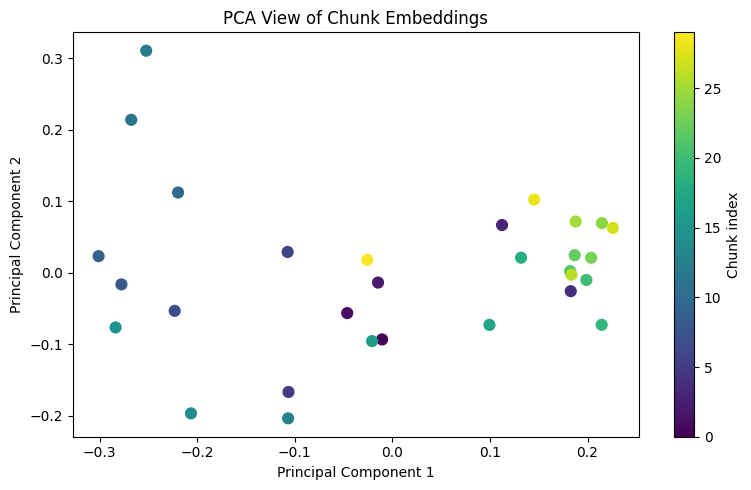

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# A small sample is enough here. The goal is to see how chunk embeddings spread out.
sample_chunks = chunks[: min(30, len(chunks))]
sample_texts = [doc.page_content for doc in sample_chunks]

if len(sample_texts) < 2:
    print("Need at least 2 chunks to plot a 2D PCA view of the embeddings.")
else:
    sample_vectors = np.array(embeddings.embed_documents(sample_texts))
    pca = PCA(n_components=2)
    coordinates = pca.fit_transform(sample_vectors)

    plt.figure(figsize=(8, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=range(len(coordinates)), cmap="viridis", s=60)
    plt.title("PCA View of Chunk Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(label="Chunk index")
    plt.tight_layout()
    plt.show()


## Student Task 2: Add a New Agent

This agent focuses only on recent developments and uses Tavily as its main tool.


In [37]:
trend_analyst = Agent(
    role="Trend Analyst",
    goal="Summarize the latest news and trends on a given AI topic.",
    backstory=(
        "You track current developments, keep the summary focused, "
        "and highlight the most relevant changes rather than dumping raw search output."
    ),
    tools=[search_web],
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

trend_task = Task(
    description=(
        "Search the web and summarize the latest news on: AI agents in healthcare\n"
        "Return 5 short bullet points with the main takeaway from each."
    ),
    expected_output="Five concise bullet points covering the latest trend updates.",
    agent=trend_analyst,
)

trend_crew = Crew(agents=[trend_analyst], tasks=[trend_task], process=Process.sequential, verbose=True)
trend_summary = trend_crew.kickoff()
print(trend_summary)


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 1416fe18-7816-4a43-8cd2-706cf5663e0e                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Search the web and summarize the latest news on: AI agents in healthcare                                 │
│  Return 5 short bullet points with the main takeaway from each.                                                 │
│  ID: bba5e116-6820-424d-958b-973b380788fc                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Trend Analyst                                                                                           │
│                                                                                                                 │
│  Task: Search the web and summarize the latest news on: AI agents in healthcare                                 │
│  Return 5 short bullet points with the main takeaway from each.                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#6) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: search_web                                                                                               │
│  Args: {'question': 'AI agents in healthcare latest news and trends'}                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool search_web executed with result: [1] The Latest AI News + Breakthroughs in Healthcare and Medical
URL: https://www.crescendo.ai/news/ai-in-healthcare-news
Content: News Date: September 29, 2025

dHealth Intelligence has unveiled a fi...


...

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Search the web and summarize the latest news on: AI agents in healthcare                                 │
│  Return 5 short bullet points with the main takeaway from each.                                                 │
│  Agent: Trend Analyst                                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[CrewAIEventsBus] Warning: Event pairing mismatch. 'crew_kickoff_completed' closed 'task_started' (expected 
'crew_kickoff_started')

Here are five concise bullet points covering the latest trend updates on AI agents in healthcare:

* dHealth Intelligence has introduced an AI agent that consolidates fragmented medical data into a unified narrative and provides private, medical-grade AI consultations.
* The global AI in healthcare market is projected to grow from $26.6 billion in 2024 to nearly $187 billion by 2030 at a CAGR of ~38.5%.
* Salt AI has secured $10 million in funding to scale its contextual AI platform, designed to accelerate adoption of AI in life sciences and healthcare.
* Researchers have introduced Delphi-2M, an AI model capable of predicting long-term disease trajectories across more than 1,000 conditions, enabling personalized healthcare planning.
* Stanford University has launched MedAgentBench, a benchmark that evaluates AI agents in real-world healthcare scenarios using de-identified patient data.


╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 1416fe18-7816-4a43-8cd2-706cf5663e0e                                                                       │
│  Final Output: Here are five concise bullet points covering the latest trend updates on AI agents in            │
│  healthcare:                                                                                                    │
│                                                                                                                 │
│  * dHealth Intelligence has introduced an AI agent that consolidates fragmented medical data into a unified     │
│  narrative and provides private, medical-grade AI consultations.                                                │
│  * The global AI in healthcare market is projected to grow from $26.6 billion in 2024 to nearly $187 billion    │
│  by 2030 at a CAGR of ~38.5%.                                                                                   │
│  * Salt AI has secured $10 million in funding to scale its contextual AI platform, designed to accelerate       │
│  adoption of AI in life sciences and healthcare.                                                                │
│  * Researchers have introduced Delphi-2M, an AI model capable of predicting long-term disease trajectories      │
│  across more than 1,000 conditions, enabling personalized healthcare planning.                                  │
│  * Stanford University has launched MedAgentBench, a benchmark that evaluates AI agents in real-world           │
│  healthcare scenarios using de-identified patient data.                                                         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Student Task 3: Report Generator Agent

This part creates a markdown report and saves it in the `reports/` folder.


In [38]:
report_generator = Agent(
    role="Report Generator",
    goal="Create a structured markdown report grounded in both local documents and live web findings.",
    backstory=(
        "You write practical research reports. You keep the structure sharp, "
        "call out limitations honestly, and make the report useful to a reader who wants the big picture quickly."
    ),
    tools=[],
    llm=crew_llm,
    allow_delegation=False,
    verbose=True,
)

report_task = Task(
    description=(
        "Write a markdown report on: AI in clinical summarization\n\n"
        "Include these sections exactly:\n"
        "1. Executive Summary\n"
        "2. Key Findings\n"
        "3. Challenges and Limitations\n"
        "4. Future Outlook\n"
        "5. Conclusion\n"
        "6. Sources\n\n"
        "Use the knowledge base and web search where appropriate."
    ),
    expected_output="A complete markdown report with the requested sections.",
    agent=report_generator,
)

report_crew = Crew(agents=[report_generator], tasks=[report_task], process=Process.sequential, verbose=True)
report_output = report_crew.kickoff()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_path = REPORTS_DIR / f"report_{timestamp}.md"
report_path.write_text(str(report_output), encoding="utf-8")

print(f"Saved report to {report_path}")
print(str(report_output)[:1200])


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 669a1e7c-16af-4cef-a507-70e4024db9e3                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Write a markdown report on: AI in clinical summarization                                                 │
│                                                                                                                 │
│  Include these sections exactly:                                                                                │
│  1. Executive Summary                                                                                           │
│  2. Key Findings                                                                                                │
│  3. Challenges and Limitations                                                                                  │
│  4. Future Outlook                                                                                              │
│  5. Conclusion                                                                                                  │
│  6. Sources                                                                                                     │
│                                                                                                                 │
│  Use the knowledge base and web search where appropriate.                                                       │
│  ID: a431a0ef-070d-4040-ae6b-b61d2e7e187f                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Task: Write a markdown report on: AI in clinical summarization                                                 │
│                                                                                                                 │
│  Include these sections exactly:                                                                                │
│  1. Executive Summary                                                                                           │
│  2. Key Findings                                                                                                │
│  3. Challenges and Limitations                                                                                  │
│  4. Future Outlook                                                                                              │
│  5. Conclusion                                                                                                  │
│  6. Sources                                                                                                     │
│                                                                                                                 │
│  Use the knowledge base and web search where appropriate.                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # AI in Clinical Summarization: A Review of Current Developments and Future Directions                         │
│  ## 1. Executive Summary                                                                                        │
│                                                                                                                 │
│  Artificial intelligence (AI) is increasingly being applied to clinical summarization, a critical task in       │
│  healthcare that involves condensing large volumes of patient data into concise, clinically relevant            │
│  summaries. This report provides an overview of the current state of AI in clinical summarization,              │
│  highlighting key findings, challenges, limitations, and future outlook. Our analysis reveals that while AI     │
│  has the potential to significantly enhance the efficiency and accuracy of clinical summarization, several      │
│  challenges must be addressed to fully realize its benefits.                                                    │
│                                                                                                                 │
│  ## 2. Key Findings                                                                                             │
│                                                                                                                 │
│  * **Natural Language Processing (NLP) and Machine Learning (ML)**: NLP and ML are the foundational             │
│  technologies driving AI applications in clinical summarization. These technologies enable the extraction of    │
│  relevant information from unstructured clinical text and the generation of concise summaries.                  │
│  * **Improved Efficiency and Accuracy**: Studies have shown that AI-powered clinical summarization tools can    │
│  significantly reduce the time healthcare professionals spend on documentation, while also improving the        │
│  accuracy and consistency of summaries.                                                                         │
│  * **Integration with Electronic Health Records (EHRs)**: The integration of AI-powered clinical summarization  │
│  tools with EHR systems is a key trend, enabling seamless access to patient data and facilitating the           │
│  generation of summaries.                                                                                       │
│  * **Clinical Validation**: Several clinical validation studies have demonstrated the effectiveness of          │
│  AI-generated clinical summaries, with some indicating that these summaries can be as accurate as, or even      │
│  surpass, those generated by human clinicians.                                                                  │
│                                                                                                                 │
│  ## 3. Challenges and Limitations                                                                               │
│                                                                                                                 │
│  * **Data Quality and Availability**: The performance of AI models is highly dependent on the quality and       │
│  availability of training data. Limited access to high-quality, annotated datasets hinders the development and  │
│  validation of AI-powered clinical summarization tools.

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Write a markdown report on: AI in clinical summarization                                                 │
│                                                                                                                 │
│  Include these sections exactly:                                                                                │
│  1. Executive Summary                                                                                           │
│  2. Key Findings                                                                                                │
│  3. Challenges and Limitations                                                                                  │
│  4. Future Outlook                                                                                              │
│  5. Conclusion                                                                                                  │
│  6. Sources                                                                                                     │
│                                                                                                                 │
│  Use the knowledge base and web search where appropriate.                                                       │
│  Agent: Report Generator                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Saved report to /content/reports/report_20260327_211913.md
# AI in Clinical Summarization: A Review of Current Developments and Future Directions
## 1. Executive Summary

Artificial intelligence (AI) is increasingly being applied to clinical summarization, a critical task in healthcare that involves condensing large volumes of patient data into concise, clinically relevant summaries. This report provides an overview of the current state of AI in clinical summarization, highlighting key findings, challenges, limitations, and future outlook. Our analysis reveals that while AI has the potential to significantly enhance the efficiency and accuracy of clinical summarization, several challenges must be addressed to fully realize its benefits.

## 2. Key Findings

* **Natural Language Processing (NLP) and Machine Learning (ML)**: NLP and ML are the foundational technologies driving AI applications in clinical summarization. These technologies enable the extraction of relevant information from

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 669a1e7c-16af-4cef-a507-70e4024db9e3                                                                       │
│  Final Output: # AI in Clinical Summarization: A Review of Current Developments and Future Directions           │
│  ## 1. Executive Summary                                                                                        │
│                                                                                                                 │
│  Artificial intelligence (AI) is increasingly being applied to clinical summarization, a critical task in       │
│  healthcare that involves condensing large volumes of patient data into concise, clinically relevant            │
│  summaries. This report provides an overview of the current state of AI in clinical summarization,              │
│  highlighting key findings, challenges, limitations, and future outlook. Our analysis reveals that while AI     │
│  has the potential to significantly enhance the efficiency and accuracy of clinical summarization, several      │
│  challenges must be addressed to fully realize its benefits.                                                    │
│                                                                                                                 │
│  ## 2. Key Findings                                                                                             │
│                                                                                                                 │
│  * **Natural Language Processing (NLP) and Machine Learning (ML)**: NLP and ML are the foundational             │
│  technologies driving AI applications in clinical summarization. These technologies enable the extraction of    │
│  relevant information from unstructured clinical text and the generation of concise summaries.                  │
│  * **Improved Efficiency and Accuracy**: Studies have shown that AI-powered clinical summarization tools can    │
│  significantly reduce the time healthcare professionals spend on documentation, while also improving the        │
│  accuracy and consistency of summaries.                                                                         │
│  * **Integration with Electronic Health Records (EHRs)**: The integration of AI-powered clinical summarization  │
│  tools with EHR systems is a key trend, enabling seamless access to patient data and facilitating the           │
│  generation of summaries.                                                                                       │
│  * **Clinical Validation**: Several clinical validation studies have demonstrated the effectiveness of          │
│  AI-generated clinical summaries, with some indicating that these summaries can be as accurate as, or even      │
│  surpass, those generated by human clinicians.                                                                  │
│                                                                                                                 │
│  ## 3. Challenges and Limitations                                                                               │
│                                                                                                                 │
│  * **Data Quality and Availability**: The performance of AI models is highly dependent on the quality and       │
│  availability of training data. Limited access to high-quality, annotated datasets hinders the development and  │
│  validation of AI-powered clinical summarization tools

## Optional: Interactive Question Loop

Run this only when you want to keep asking questions in one session.


In [ ]:
def ask_with_agents(question: str):
    crew = build_qa_crew(question)
    return crew.kickoff()


print("Ask a question about your local documents or a current topic. Leave it blank to stop.\n")

while True:
    user_question = input("Question: ").strip()
    if not user_question:
        print("Session ended.")
        break

    print("\nAnswer:\n")
    print(ask_with_agents(user_question))
    print("\n" + "-" * 80 + "\n")


Ask a question about your local documents or a current topic. Leave it blank to stop.

Question: The Role of AI in Clinical Summarization what is this?

Answer:



╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 541828ba-04e7-490c-b45d-77ce15bfe761                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the following question: The Role of AI in Clinical Summarization what is this?                  │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│  ID: 42bf57e9-b668-47b2-9343-85aa75e56b7b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Task: Research the following question: The Role of AI in Clinical Summarization what is this?                  │
│                                                                                                                 │
│  Use the local knowledge base first whenever it is relevant. Use Tavily web search for recent facts, missing    │
│  context, or current developments.                                                                              │
│  Return well-organized research notes with clear source labels.                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Researcher                                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The Role of AI in Clinical Summarization refers to the use of Artificial Intelligence (AI) to condense and     │
│  summarize complex medical information from various sources, including patient records, literature, and         │
│  biomedical texts. This process aims to improve the efficiency and accuracy of clinical decision-making,        │
│  reduce administrative burdens, and enhance patient care.                                                       │
│                                                                                                                 │
│  AI-powered clinical summarization tools can:                                                                   │
│                                                                                                                 │
│  1. **Summarize patient records**: Quickly condense lengthy patient records into concise, relevant              │
│  information, enabling clinicians to focus on high-priority tasks.                                              │
│  2. **Support clinical decisions**: Provide clinicians with relevant insights, recommendations, and diagnostic  │
│  codes to inform treatment planning.                                                                            │
│  3. **Reduce administrative burdens**: Automate documentation tasks, such as generating notes, referral         │
│  letters, and discharge summaries.                                                                              │
│  4. **Improve patient-centered care**: Enhance the quality and efficiency of care by reducing information       │
│  overload and enabling clinicians to devote more time to direct patient care.                                   │
│                                                                                                                 │
│  Recent studies and developments in AI clinical summarization include:                                          │
│                                                                                                                 │
│  * **Significant speed improvements**: AI-powered summarization tools have demonstrated a 22.2x speed increase  │
│  in creating medical summaries.                                                                                 │
│  * **Integration with clinical workflows**: AI summarization tools are being integrated into electronic health  │
│  records (EHRs) and clinical workflows to streamline patient care.                                              │
│  * **Addressing challenges**: Ongoing efforts focus on addressing challenges related to data structure,         │
│  representativeness, and ethical considerations in AI-driven clinical summarization.                            │
│                                                                                                                 │
│  Sources:                                                                                                       │
│                                                                                                                 │
│  1. Abstractive Health - AI Medical Record Summarization: The Guide for Clinicians                              │
│  2. Testicular Cancer Organization - AI-Powered Summarization: Improving Oncology Care                          │
│  3. Frontiers in Digital Health - Prospects for AI clin

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **The Role of AI in Clinical Summarization**                                                                   │
│                                                                                                                 │
│  The Role of AI in Clinical Summarization refers to the use of Artificial Intelligence (AI) to condense and     │
│  summarize complex medical information from various sources, including patient records, literature, and         │
│  biomedical texts. This process aims to improve the efficiency and accuracy of clinical decision-making,        │
│  reduce administrative burdens, and enhance patient care.                                                       │
│                                                                                                                 │
│  AI-powered clinical summarization tools can:                                                                   │
│                                                                                                                 │
│  1. **Summarize patient records**: Quickly condense lengthy patient records into concise, relevant              │
│  information, enabling clinicians to focus on high-priority tasks.                                              │
│  2. **Support clinical decisions**: Provide clinicians with relevant insights, recommendations, and diagnostic  │
│  codes to inform treatment planning.                                                                            │
│  3. **Reduce administrative burdens**: Automate documentation tasks, such as generating notes, referral         │
│  letters, and discharge summaries.                                                                              │
│  4. **Improve patient-centered care**: Enhance the quality and efficiency of care by reducing information       │
│  overload and enabling clinicians to devote more time to direct patient care.                                   │
│                                                                                                                 │
│  Recent studies and developments in AI clinical summarization include:                                          │
│                                                                                                                 │
│  * **Significant speed improvements**: AI-powered summarization tools have demonstrated a 22.2x speed increase  │
│  in creating medical summaries.                                                                                 │
│  * **Integration with clinical workflows**: AI summarization tools are being integrated into electronic health  │
│  records (EHRs) and clinical workflows to streamline patient care.                                              │
│  * **Addressing challenges**: Ongoing efforts focus on addressing challenges related to data structure,         │
│  representativeness, and ethical considerations in AI-driven clinical summarization.                            │
│                                                                                                                 │
│  The use of AI in clinical summarization has the potential to revolutionize the way clinicians work with        │
│  patient data, enabling them to make more informed decisions, reduce administrative tasks, and focus on         │
│  delivering high-quality patient care. By automating th

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Review the draft answer for this question: The Role of AI in Clinical Summarization what is this?        │
│                                                                                                                 │
│  Check factual grounding, clarity, and completeness. Return the improved final answer, followed by a short      │
│  'Sources' section.                                                                                             │
│  Agent: Reviewer                                                                                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 541828ba-04e7-490c-b45d-77ce15bfe761                                                                       │
│  Final Output: **The Role of AI in Clinical Summarization**                                                     │
│                                                                                                                 │
│  The Role of AI in Clinical Summarization refers to the use of Artificial Intelligence (AI) to condense and     │
│  summarize complex medical information from various sources, including patient records, literature, and         │
│  biomedical texts. This process aims to improve the efficiency and accuracy of clinical decision-making,        │
│  reduce administrative burdens, and enhance patient care.                                                       │
│                                                                                                                 │
│  AI-powered clinical summarization tools can:                                                                   │
│                                                                                                                 │
│  1. **Summarize patient records**: Quickly condense lengthy patient records into concise, relevant              │
│  information, enabling clinicians to focus on high-priority tasks.                                              │
│  2. **Support clinical decisions**: Provide clinicians with relevant insights, recommendations, and diagnostic  │
│  codes to inform treatment planning.                                                                            │
│  3. **Reduce administrative burdens**: Automate documentation tasks, such as generating notes, referral         │
│  letters, and discharge summaries.                                                                              │
│  4. **Improve patient-centered care**: Enhance the quality and efficiency of care by reducing information       │
│  overload and enabling clinicians to devote more time to direct patient care.                                   │
│                                                                                                                 │
│  Recent studies and developments in AI clinical summarization include:                                          │
│                                                                                                                 │
│  * **Significant speed improvements**: AI-powered summarization tools have demonstrated a 22.2x speed increase  │
│  in creating medical summaries.                                                                                 │
│  * **Integration with clinical workflows**: AI summarization tools are being integrated into electronic health  │
│  records (EHRs) and clinical workflows to streamline patient care.                                              │
│  * **Addressing challenges**: Ongoing efforts focus on addressing challenges related to data structure,         │
│  representativeness, and ethical considerations in AI-driven clinical summarization.                            │
│                                                                                                                 │
│  The use of AI in clinical summarization has the potential to revolutionize the way clinicians work with        │
│  patient data, enabling them to make more informed decisions, reduce administrative tasks, and focus on         │
│  delivering high-quality patient care. By automating t

**The Role of AI in Clinical Summarization**

The Role of AI in Clinical Summarization refers to the use of Artificial Intelligence (AI) to condense and summarize complex medical information from various sources, including patient records, literature, and biomedical texts. This process aims to improve the efficiency and accuracy of clinical decision-making, reduce administrative burdens, and enhance patient care.

AI-powered clinical summarization tools can:

1. **Summarize patient records**: Quickly condense lengthy patient records into concise, relevant information, enabling clinicians to focus on high-priority tasks.
2. **Support clinical decisions**: Provide clinicians with relevant insights, recommendations, and diagnostic codes to inform treatment planning.
3. **Reduce administrative burdens**: Automate documentation tasks, such as generating notes, referral letters, and discharge summaries.
4. **Improve patient-centered care**: Enhance the quality and efficiency of care by reduc

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Final Notes

What changed compared with the earlier version:
- local data now comes from `crew_data/` as required
- the vectorstore is FAISS-based and reusable across tasks
- `.env` secrets are loaded safely instead of being described as hardcoded values
- the CrewAI flow now uses the exact Researcher, Writer, and Critic roles requested in the brief
- the trend analyst and report generator tasks are included
- comments and markdown were rewritten to sound natural and clear

If you want to extend the project further, the next sensible upgrades are:
- swap FAISS for Chroma and compare retrieval quality
- add a Streamlit or Flask interface
- export reports to PDF
- test different chunk sizes, overlap values, and embedding models
